# Modeling a High Resolution Reflection Spectrum with new ExoMol CH4

Hajime Kawahara July 7th (2024)

In [1]:
import os

# Enable Numba before the first miepython import.
os.environ.setdefault("MIEPYTHON_USE_JIT", "1")

from jax import config
config.update("jax_enable_x64", True)


Set the data directory and the path to the LATMOS solar spectrum. The defaults are relative to this notebook; the environment variables allow an existing data cache to be reused. Download the [LATMOS solar spectrum](https://vizier.cfa.harvard.edu/ftp/cats/vi/159/sp/Spectre_HR_LATMOS_Meftah_V1.txt) to the default solar path, or set `EXOJAX_SOLAR_SPECTRUM` to its local filename.

In [2]:
from pathlib import Path

database_path = Path(os.environ.get("EXOJAX_DATABASE", ".database"))
solar_spectrum_path = Path(os.environ.get(
    "EXOJAX_SOLAR_SPECTRUM",
    database_path / "solar" / "Spectre_HR_LATMOS_Meftah_V1.txt",
))
database_path.mkdir(parents=True, exist_ok=True)



We need to get `JoviSpec`, the repository that contains the real reflection spectra of Jupiter. 

```sh
git clone https://github.com/HajimeKawahara/jovispec.git
python setup.py install
```


In [3]:
from jovispec import abcio
from importlib.resources import files


jupiter_data = str(files("jovispec") / "jupiter_data")

# red
rlambc, rspecc, rheadc = abcio.read_qfits("06033", jupiter_data, ext="q")
rlambw, rspecw, rheadw = abcio.read_qfits("06047", jupiter_data, ext="q")
rlambe, rspece, rheade = abcio.read_qfits("06049", jupiter_data, ext="q")

# rapid rotator
rlamb_ref, rspec_ref, rhead_ref = abcio.read_qfits(
    "06031", jupiter_data, ext="q"
)  # HD13041

# blue
# rlambc, rspecc, rheadc=abcio.read_qfits("06034",jupiter_data,ext="q")
# rlambw, rspecw, rheaadw=abcio.read_qfits("06048",jupiter_data,ext="q")
# rlambe, rspece, rheade=abcio.read_qfits("06050",jupiter_data,ext="q")

Sets the wavelength range

In [4]:
wavelength_start = 8500.0 #AA
wavelength_end = 8800.0 #AA

You find almost no telluric lines in this wavelength range

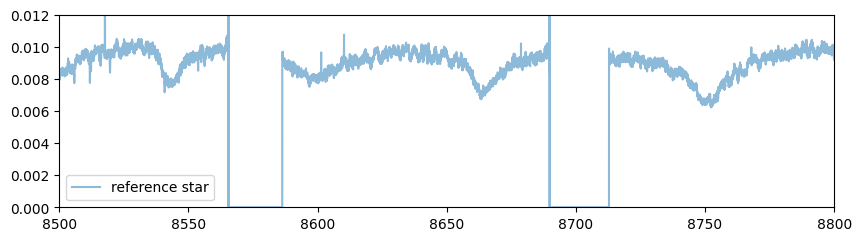

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,2.5))
ax = fig.add_subplot(111)
plt.plot(rlamb_ref,rspec_ref,alpha=0.5,label="reference star")
plt.ylim(0.0,0.012)
plt.xlim(wavelength_start,wavelength_end)
plt.legend()
plt.show()

We observed the east edge, center, and west edge of the Jovian disk.
The rapid spin rotation yields different Doppler shift for these observataions

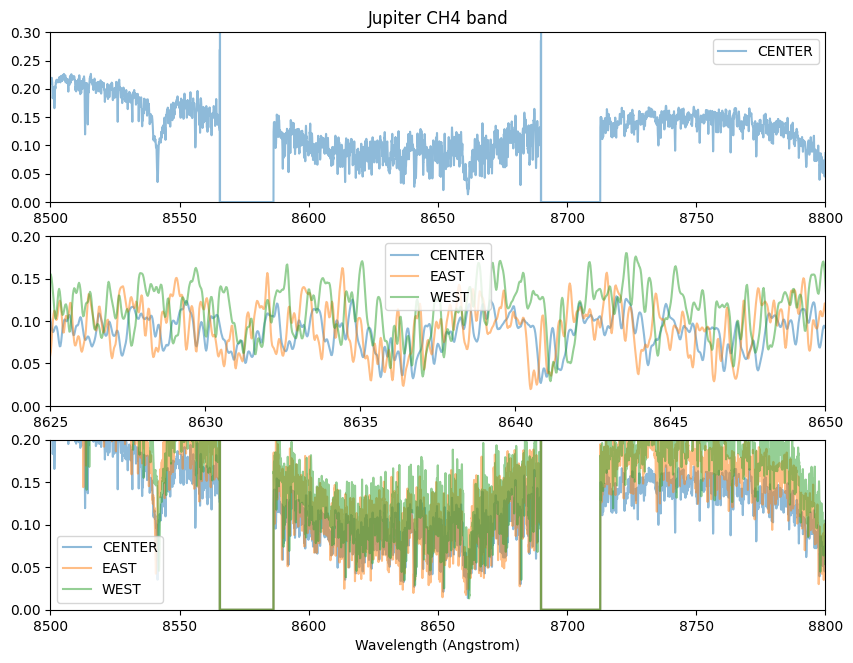

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,7.5))
ax = fig.add_subplot(311)
plt.plot(rlambc,rspecc,alpha=0.5,label="CENTER")
#plt.plot(rlambe,rspece,alpha=0.5,label="EAST")
#plt.plot(rlambw,rspecw*0.7,alpha=0.5,label="WEST")
plt.ylim(0.0,0.3)
plt.xlim(wavelength_start,wavelength_end)
plt.legend()
plt.title("Jupiter CH4 band")

#plt.xlim(7150.0,7200.0)
ax = fig.add_subplot(312)
plt.plot(rlambc,rspecc,alpha=0.5,label="CENTER")
plt.plot(rlambe,rspece,alpha=0.5,label="EAST")
plt.plot(rlambw,rspecw*0.7,alpha=0.5,label="WEST")
plt.legend()
plt.ylim(0.0,0.2)
plt.xlim(wavelength_start,wavelength_end)
plt.xlim(8625,8650)

ax = fig.add_subplot(313)
plt.plot(rlambc,rspecc,alpha=0.5,label="CENTER")
plt.plot(rlambe,rspece,alpha=0.5,label="EAST")
plt.plot(rlambw,rspecw*0.7,alpha=0.5,label="WEST")
plt.legend()
plt.ylim(0.0,0.2)
plt.xlim(wavelength_start,wavelength_end)

plt.xlabel("Wavelength (Angstrom)")

plt.savefig("ch4jupiter.png")

Some messy procedure for astronomers...

In [7]:
import numpy as np

rlamb = rlambc
rspec = rspecc

# mask some bad regions... as usual in astronomy  
mask_wav = [
[8565.4, 8586.5],
[8689.5, 8713.0]
]
rlamb = np.array([float(d) for d in rlamb])
mask_index=np.digitize(mask_wav,rlamb)
for ind in mask_index:
    rspec[ind[0]:ind[1]+1] = None


# None for outside wvelength start - end region
start_index=np.digitize(wavelength_start,rlamb)
end_index=np.digitize(wavelength_end,rlamb)
rspec[:start_index] = None
rspec[end_index:] = None

#Air-Vaccum correction
from specutils.utils.wcs_utils import refraction_index
import astropy.units as u
mask = rspec == rspec
rlamb = rlamb[mask]
rspec = rspec[mask]
nair = refraction_index(rlamb*u.AA,method="Ciddor1996")
rlamb = rlamb*nair

# ascending wavenumber form
from exojax.utils.grids import wav2nu
rlamb = rlamb[::-1]
nus_obs = wav2nu(rlamb, unit="AA")
rspec = rspec[::-1]


The following spectrum is the target we will analyze (the center part of Jupiter)!

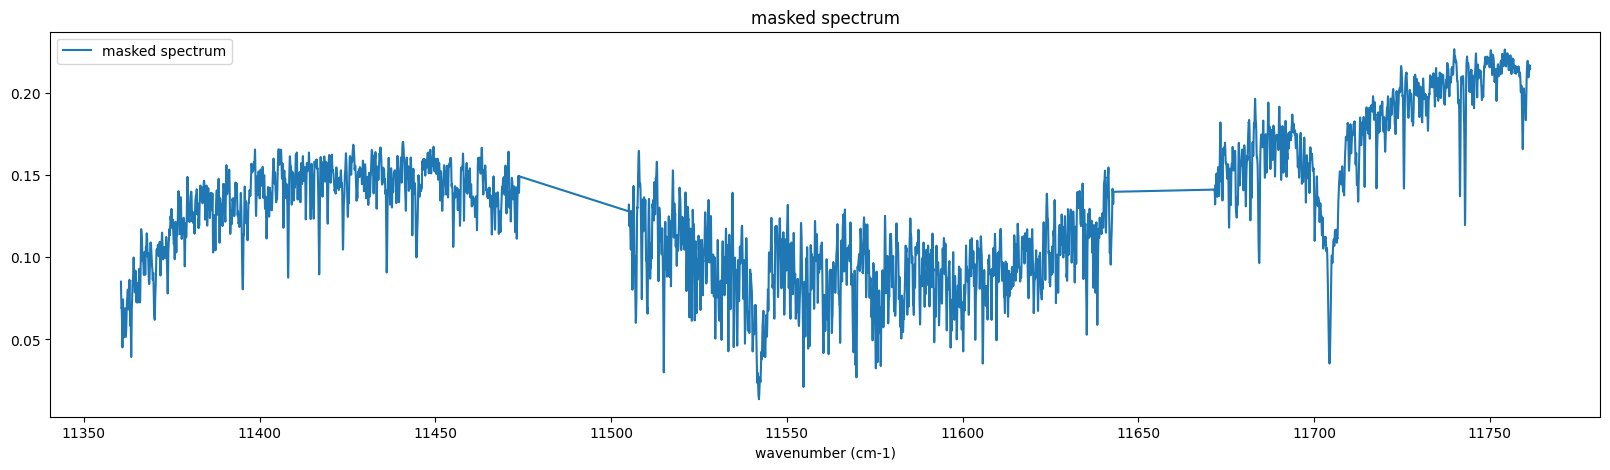

In [8]:
fig = plt.figure(figsize=(20,5))
plt.plot(nus_obs,rspec, label="masked spectrum")
plt.xlabel("wavenumber (cm-1)")
plt.legend()
plt.title("masked spectrum")
plt.show()

### Telluric

Telluric lines stuff... ExoJAX can do that anyway.

In [9]:
from exojax.database.hitran.api import MdbHitran
from exojax.opacity import OpaDirect
from exojax.opacity import OpaPremodit
from exojax.utils.grids import wavenumber_grid
from exojax.utils.grids import wav2nu

N = 40000

margin = 10  # cm-1
nus_start = wav2nu(wavelength_end, unit="AA") - margin
nus_end = wav2nu(wavelength_start, unit="AA") + margin

mdb_water = MdbHitran(database_path / "H2O", nurange=[nus_start, nus_end], isotope=1)
nus, wav, res = wavenumber_grid(nus_start, nus_end, N, xsmode="lpf", unit="cm-1")
opa_telluric = OpaPremodit(mdb_water, nu_grid=nus, allow_32bit=True, auto_trange=[80.0, 400.0])

radis engine =  vaex


xsmode =  lpf
xsmode assumes ESLOG in wavenumber space: xsmode=lpf
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
default elower grid trange (degt) file version: 2
Robust range: 79.45501192821337 - 740.1245313998245 K
OpaPremodit: gamma_air and n_air are used. gamma_ref = gamma_air/Patm


/home/kawahara/exojax/src/exojax/opacity/_common/set_ditgrid.py:62: UserWarning: There exists negative or zero value.
  warnings.warn("There exists negative or zero value.")


max value of  ngamma_ref_grid : 16.057252143496793
min value of  ngamma_ref_grid : 0.5955993376806865
ngamma_ref_grid grid : [ 0.59559929  0.69180994  0.803562    0.93336601  1.08413802  1.25926509
  1.46268146  1.69895685  1.97339917  2.29217374  2.66244181  3.09252142
  3.59207428  4.17232279  4.8463022   5.6291534   6.53846308  7.59465881
  8.82146793 10.24645062 11.901619   13.82415629 16.05725479]
max value of  n_Texp_grid : 0.78
min value of  n_Texp_grid : -0.2
n_Texp_grid grid : [-0.20000002 -0.03666667  0.12666667  0.29        0.45333333  0.61666667
  0.78000003]
Premodit: Twt= 328.42341041740974 K Tref= 91.89455622053987 K
Making LSD:|####################| 100%


Yes ah no, almost no telluric line confirmed...

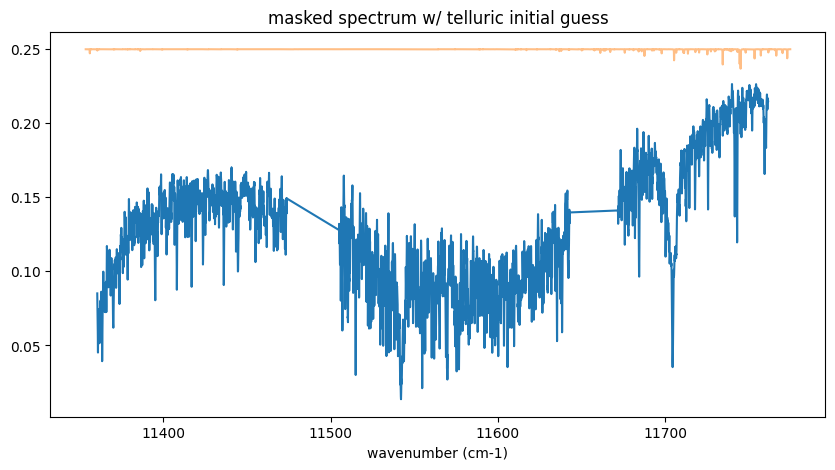

In [10]:
import jax.numpy as jnp

T = 200.0
P = 0.5
xsv = opa_telluric.xsvector(T, P)
nl = 1.0e22
a = 0.25

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
plt.title("masked spectrum w/ telluric initial guess")
plt.plot(nus_obs, rspec)
#plt.ylim(0.0, 0.7)
plt.plot(nus, a * jnp.exp(-nl * xsv), alpha=0.5)
# plt.xlim(1.e8/wavelength_start, 1.e8/wavelength_end)
plt.xlabel("wavenumber (cm-1)")

plt.show()

## Solar spectrum

This is the reflected "solar" spectrum by Jupiter! So, we need the solar spectrum template.

I found very good one: High-resolution solar spectrum taken from Meftar et al. (2023) 

- 10.21413/SOLAR-HRS-DATASET.V1.1_LATMOS
- http://doi.latmos.ipsl.fr/DOI_SOLAR_HRS.v1.1.html
- http://bdap.ipsl.fr/voscat_en/solarspectra.html


In [11]:

import pandas as pd
dat = pd.read_csv(solar_spectrum_path, names=("wav","flux"), comment=";", sep=r"\s+")
dat["wav"] = dat["wav"]*10

wav_solar = dat["wav"][::-1]
solspec = dat["flux"][::-1]
nus_solar = wav2nu(wav_solar,unit="AA")


This is really the solar spectrum reflected by something...

Text(0.5, 0, 'wavenumber (cm-1)')

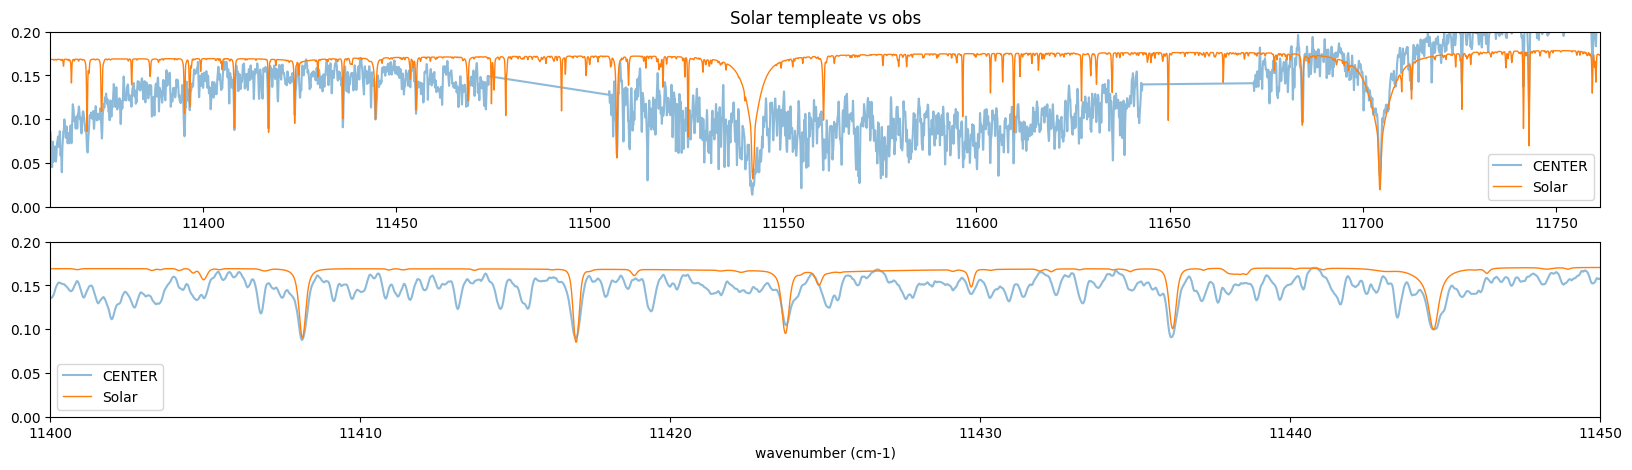

In [12]:
vrv = (106.5-82.5)
vperc = vrv/300000

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(211)
plt.plot(nus_obs,rspec,alpha=0.5,label="CENTER")
plt.plot(nus_solar*(1.0+vperc),solspec*0.17,lw=1,label="Solar")
plt.xlim(np.min(nus_obs),np.max(nus_obs))
plt.ylim(0.0,0.2)

plt.legend()
plt.title("Solar templeate vs obs")
ax = fig.add_subplot(212)
plt.plot(nus_obs,rspec,alpha=0.5,label="CENTER")
plt.plot(nus_solar*(1.0+vperc),solspec*0.17,lw=1,label="Solar")
plt.xlim(11400,11450)
plt.ylim(0.0,0.2)
plt.legend()
plt.xlabel("wavenumber (cm-1)")


## Atmospheric Model Setting

See `Jupiter_cloud_model_using_amp.ipynb` 


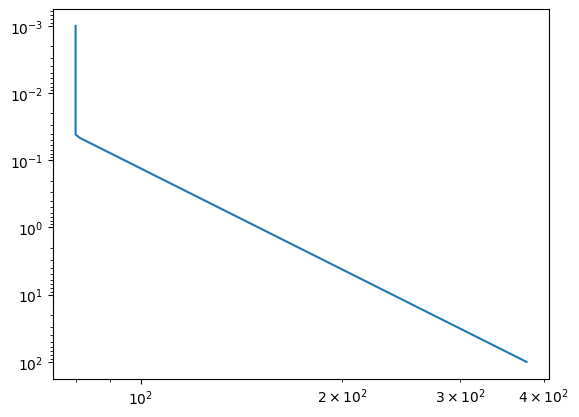

In [13]:
from exojax.rt import ArtReflectPure
from exojax.utils.astrofunc import gravity_jupiter


art = ArtReflectPure(nu_grid=nus, pressure_btm=1.0e2, pressure_top=1.0e-3, nlayer=100)
art.change_temperature_range(80.0, 400.0)
Tarr = art.powerlaw_temperature(150.0, 0.2)
Parr = art.pressure

mu = 2.3  # mean molecular weight
gravity = gravity_jupiter(1.0, 1.0)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(Tarr, art.pressure)
ax.invert_yaxis()
plt.yscale("log")
plt.xscale("log")
plt.show()

In [14]:


from exojax.database.pardb  import PdbCloud
from exojax.atm.atmphys import AmpAmcloud

pdb_nh3 = PdbCloud("NH3", path=database_path / "particulates/virga")
amp_nh3 = AmpAmcloud(pdb_nh3, bkgatm="H2")
amp_nh3.check_temperature_range(Tarr)

#condensate substance density
rhoc = pdb_nh3.condensate_substance_density #g/cc

from exojax.utils.zsol import nsol
from exojax.atm.atmconvert import vmr_to_mmr
from exojax.database.molinfo  import molmass_isotope

n = nsol()  #solar abundance
abundance_nh3 = n["N"]
molmass_nh3 = molmass_isotope("NH3", db_HIT=False)

fsed = 10.
sigmag = 2.0
Kzz = 1.e4
MMRbase_nh3 = vmr_to_mmr(abundance_nh3, molmass_nh3, mu) 

rg_layer, MMRc = amp_nh3.calc_ammodel(Parr, Tarr, mu, molmass_nh3, gravity, fsed, sigmag, Kzz, MMRbase_nh3)


/tmp/exojax-mie-tutorials/hires-exomol/.database/particulates/virga/virga.zip  exists. Remove it if you wanna re-download and unzip.
Refractive index file found:  /tmp/exojax-mie-tutorials/hires-exomol/.database/particulates/virga/NH3.refrind
Miegrid file does not exist at  /tmp/exojax-mie-tutorials/hires-exomol/.database/particulates/virga/miegrid_lognorm_NH3.mg.npz
Generate miegrid file using pdb.generate_miegrid if you use Mie scattering
Database for solar abundance =  AAG21
Asplund, M., Amarsi, A. M., & Grevesse, N. 2021, arXiv:2105.01661


/home/kawahara/exojax/src/exojax/atm/atmphys.py:55: UserWarning: min temperature 80.0 K is smaller than min(vfactor t range) 179.10000000000002 K
  warnings.warn(


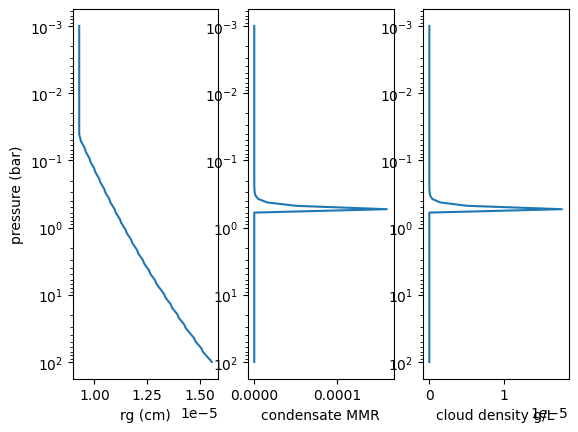

In [15]:
import matplotlib.pyplot as plt

# to convert MMR to g/L ... 
from exojax.atm.idealgas import number_density
from exojax.utils.constants import m_u
fac = mu*m_u*number_density(Parr,Tarr)*1.e3 # g/L per unit condensate MMR 

fig = plt.figure()
ax = fig.add_subplot(131)
plt.plot(rg_layer, Parr)
plt.xlabel("rg (cm)")
plt.ylabel("pressure (bar)")
plt.yscale("log")
ax.invert_yaxis()
ax = fig.add_subplot(132)
plt.plot(MMRc, Parr)
plt.xlabel("condensate MMR")
plt.yscale("log")
#plt.xscale("log")
ax.invert_yaxis()
ax = fig.add_subplot(133)
plt.plot(fac*MMRc, Parr)
plt.xlabel("cloud density g/L")
plt.yscale("log")
#plt.xscale("log")
ax.invert_yaxis()

In [16]:
rg = 1.e-5

from exojax.opacity import OpaMie
opa = OpaMie(pdb_nh3, nus)
#sigma_extinction, sigma_scattering, asymmetric_factor = opa.mieparams_vector(rg,sigmag) # if using MieGrid
sigma_extinction, sigma_scattering, asymmetric_factor = opa.mieparams_vector_direct(rg, sigmag)


  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:01<00:04,  1.05s/it]

100%|██████████| 5/5 [00:01<00:00,  4.67it/s]

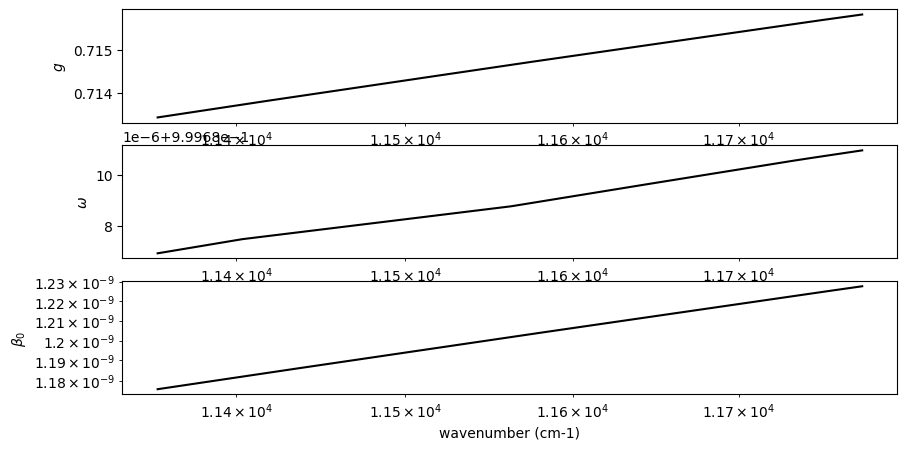

In [17]:
# plt.plot(pdb_nh3.refraction_index_wavenumber, miepar[50,:,0])
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(311)
plt.plot(nus, asymmetric_factor, color="black")
plt.xscale("log")
plt.ylabel("$g$")
ax = fig.add_subplot(312)
plt.plot(nus, sigma_scattering/sigma_extinction, label="single scattering albedo", color="black")
plt.xscale("log")
plt.ylabel("$\\omega$")
ax = fig.add_subplot(313)
plt.plot(nus, sigma_extinction, label="ext", color="black")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("wavenumber (cm-1)")
plt.ylabel("$\\beta_0$")
plt.savefig("miefig_high.png")

Next, we consider the gas component, i.e. methane

In [18]:
from exojax.database.exomol.api import MdbExomol

Ignore the following unless you are interested in the elower max optimization

In [19]:
optimize = False #if you want to run the elower maximum optimization, turn True
if optimize:
    mdb = MdbExomol(database_path / "CH4/12C-1H4/MM", nurange=[nus_start,nus_end], engine="pytables")
    from exojax.opacity.premodit.optgrid import optelower
    Tmax = 400.0
    Pmin = 1.e-5
    Eopt = optelower(mdb, nus, Tmax, Pmin)

In [20]:
nus_start, nus_end


(11353.636363636364, 11774.70588235294)

Oh, we need HITEMP because our observation is in visible band, i.e., we need higher energy states.

In [21]:
Eopt = 3300.0 # this is from the above optimization result
mdb_reduced = MdbExomol(database_path / "CH4/12C-1H4/MM", nurange=[nus_start,nus_end], elower_max=Eopt, engine="pytables")

/home/kawahara/exojax/src/exojax/utils/molname.py:197: FutureWarning: e2s will be replaced to exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:63: UserWarning: No isotope number identified.
  warnings.warn("No isotope number identified.", UserWarning)
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:63: UserWarning: No isotope number identified.
  warnings.warn("No isotope number identified.", UserWarning)
/home/kawahara/exojax/src/exojax/database/molinfo/mass.py:48: UserWarning: exac

HITRAN exact name= (12C)(1H)4
HITRAN exact name= (12C)(1H)4
radis engine =  pytables


Broadener:  H2
Broadening code level: a1


/home/kawahara/miniconda3/lib/python3.12/site-packages/radis/api/exomolapi.py:728: AccuracyWarning: The default broadening parameter (alpha = 0.0488 cm^-1 and n = 0.4) are used for J'' > 16 up to J'' = 25
  warnings.warn(


The optimization stuff, ignore

In [22]:
if optimize:
    plt.plot(mdb.elower,mdb.line_strength_ref,".",alpha=0.3)
    plt.plot(mdb_reduced.elower,mdb_reduced.line_strength_ref,".",alpha=0.5,color="C2")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("E lower (cm-1)")
    plt.ylabel("line strength at T="+str(mdb.Tref)+"K")
    plt.axvline(Eopt, color="C2")

In [23]:
opa = OpaPremodit(mdb_reduced, nu_grid=nus, allow_32bit=True, auto_trange=[80.0, 300.0]) #this reduced the device memory use in 5/6.

default elower grid trange (degt) file version: 2
Robust range: 79.45501192821337 - 740.1245313998245 K


max value of  ngamma_ref_grid : 8.719016705102318
min value of  ngamma_ref_grid : 5.898017332826628
ngamma_ref_grid grid : [5.89801693 6.71882299 7.65385719 8.71901798]
max value of  n_Texp_grid : 0.5
min value of  n_Texp_grid : 0.4
n_Texp_grid grid : [0.39999998 0.50000006]


Premodit: Twt= 328.42341041740974 K Tref= 91.89455622053987 K


Making LSD:|--------------------| 0%

Making LSD:|#####---------------| 25%

Making LSD:|##########----------| 50%

Making LSD:|###############-----| 75%

Making LSD:|####################| 100%


### cloud opacity

In [24]:
dtau_cld = art.opacity_profile_cloud_lognormal(sigma_extinction, rhoc, MMRc, rg, sigmag, gravity)

### gas opacity 

In [25]:
mmr_ch4 = art.constant_mmr_profile(0.02) # (*_*)/~
molmass_ch4 = molmass_isotope("CH4", db_HIT=False)

xsmatrix = opa.xsmatrix(Tarr,Parr)
dtau_ch4 = art.opacity_profile_xs(xsmatrix, mmr_ch4,molmass_ch4,gravity)

In [26]:
dtau_cld_scat = art.opacity_profile_cloud_lognormal(sigma_scattering, rhoc, MMRc, rg, sigmag, gravity)
single_scattering_albedo = (dtau_cld_scat)/(dtau_cld + dtau_ch4)

sigma_scattering[None,:]/sigma_extinction[None,:] + np.zeros((len(art.pressure), len(nus)))
asymmetric_parameter = asymmetric_factor + np.zeros((len(art.pressure), len(nus))) 
reflectivity_surface = np.zeros(len(nus))

In [27]:
dtau = dtau_cld + dtau_ch4

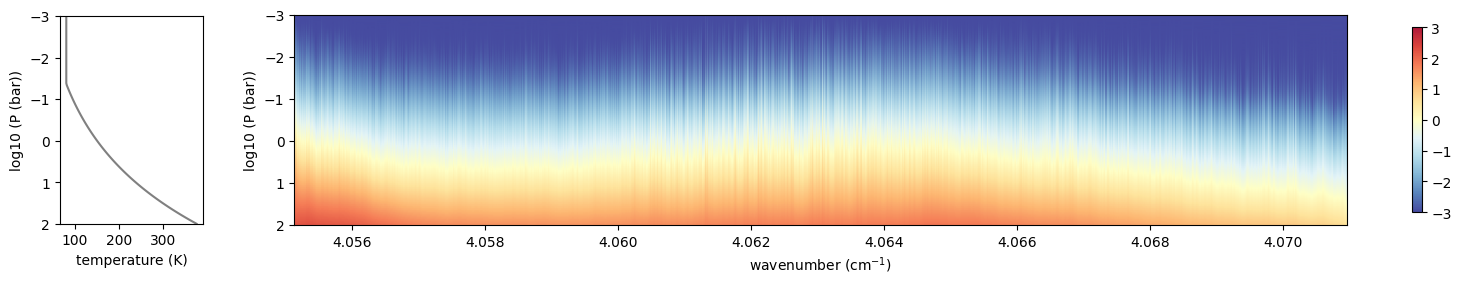

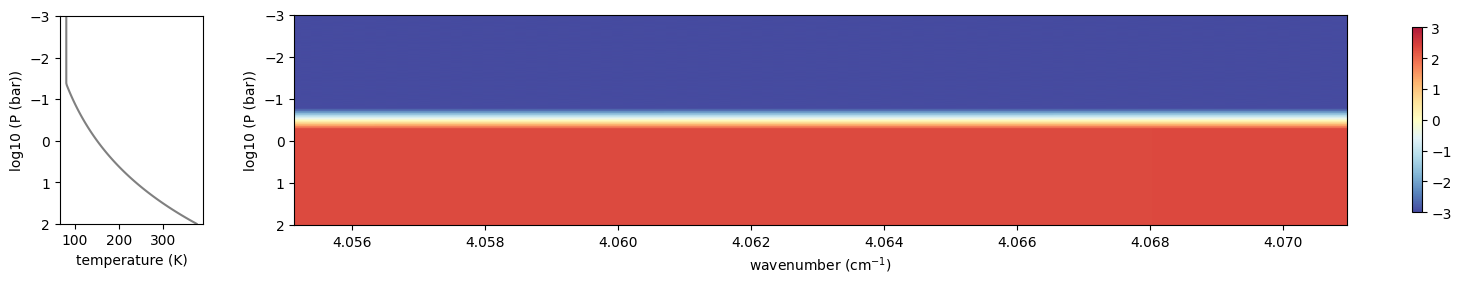

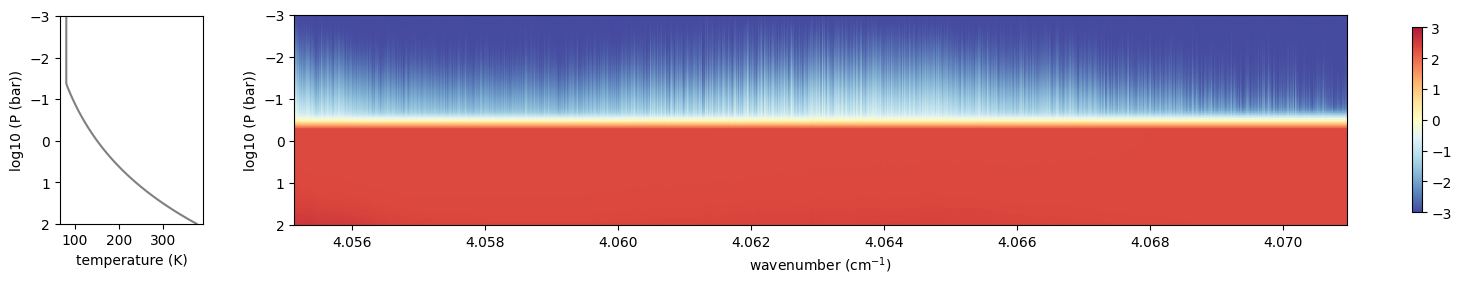

In [28]:
from exojax.plot.atmplot import plottau

plottau(np.log10(nus), dtau_ch4, Tarr, Parr)
plt.show()
plottau(np.log10(nus), dtau_cld, Tarr, Parr)
plt.show()
plottau(np.log10(nus), dtau, Tarr, Parr)

OK, uses the solar spectrum as an incomning spectrum! 

In [29]:
vv = 26.0
#vv = 0.0
vpercp = (vrv + vv) / 300000
vpercp2 = vv / 300000

# incoming_flux = np.ones(len(nus))
incoming_flux = np.interp(nus, nus_solar * (1.0 + vpercp), solspec)
Fr = art.run(
    dtau,
    single_scattering_albedo,
    asymmetric_parameter,
    reflectivity_surface,
    incoming_flux,
)

from exojax.postproc.specop import SopInstProfile
from exojax.utils.instfunc import resolution_to_gaussian_std

sop = SopInstProfile(nus)
res_inst = 80000.0
std = resolution_to_gaussian_std(res_inst)
Fr_inst = sop.ipgauss(Fr, std)
Fr_samp = sop.sampling(Fr_inst, vv, nus)

Recall that this is forward modeling. So, the following results look not bad! If you have time change the MMR of CH4 (if you find the line of `(*_*)/~`)?

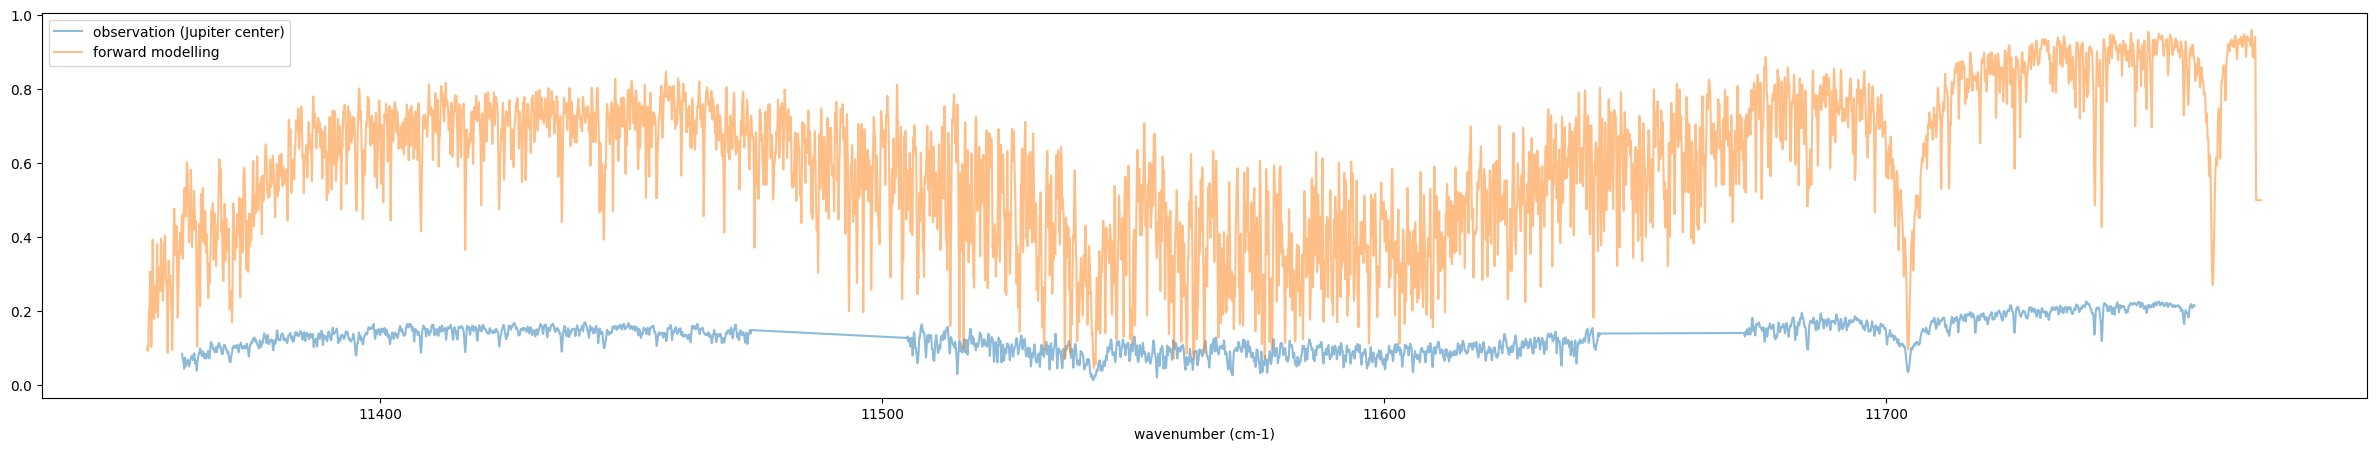

In [30]:
fig = plt.figure(figsize=(30,5))
plt.plot(nus_obs,rspec,alpha=0.5,label="observation (Jupiter center)")
plt.plot(nus,Fr_samp,alpha=0.5,label="forward modelling")
plt.legend()
plt.xlabel("wavenumber (cm-1)")
plt.savefig("Jupiter_forward.png")
plt.show()

In microscopic view, it's not so accurate (maybe Methane line list inaccuracy?)

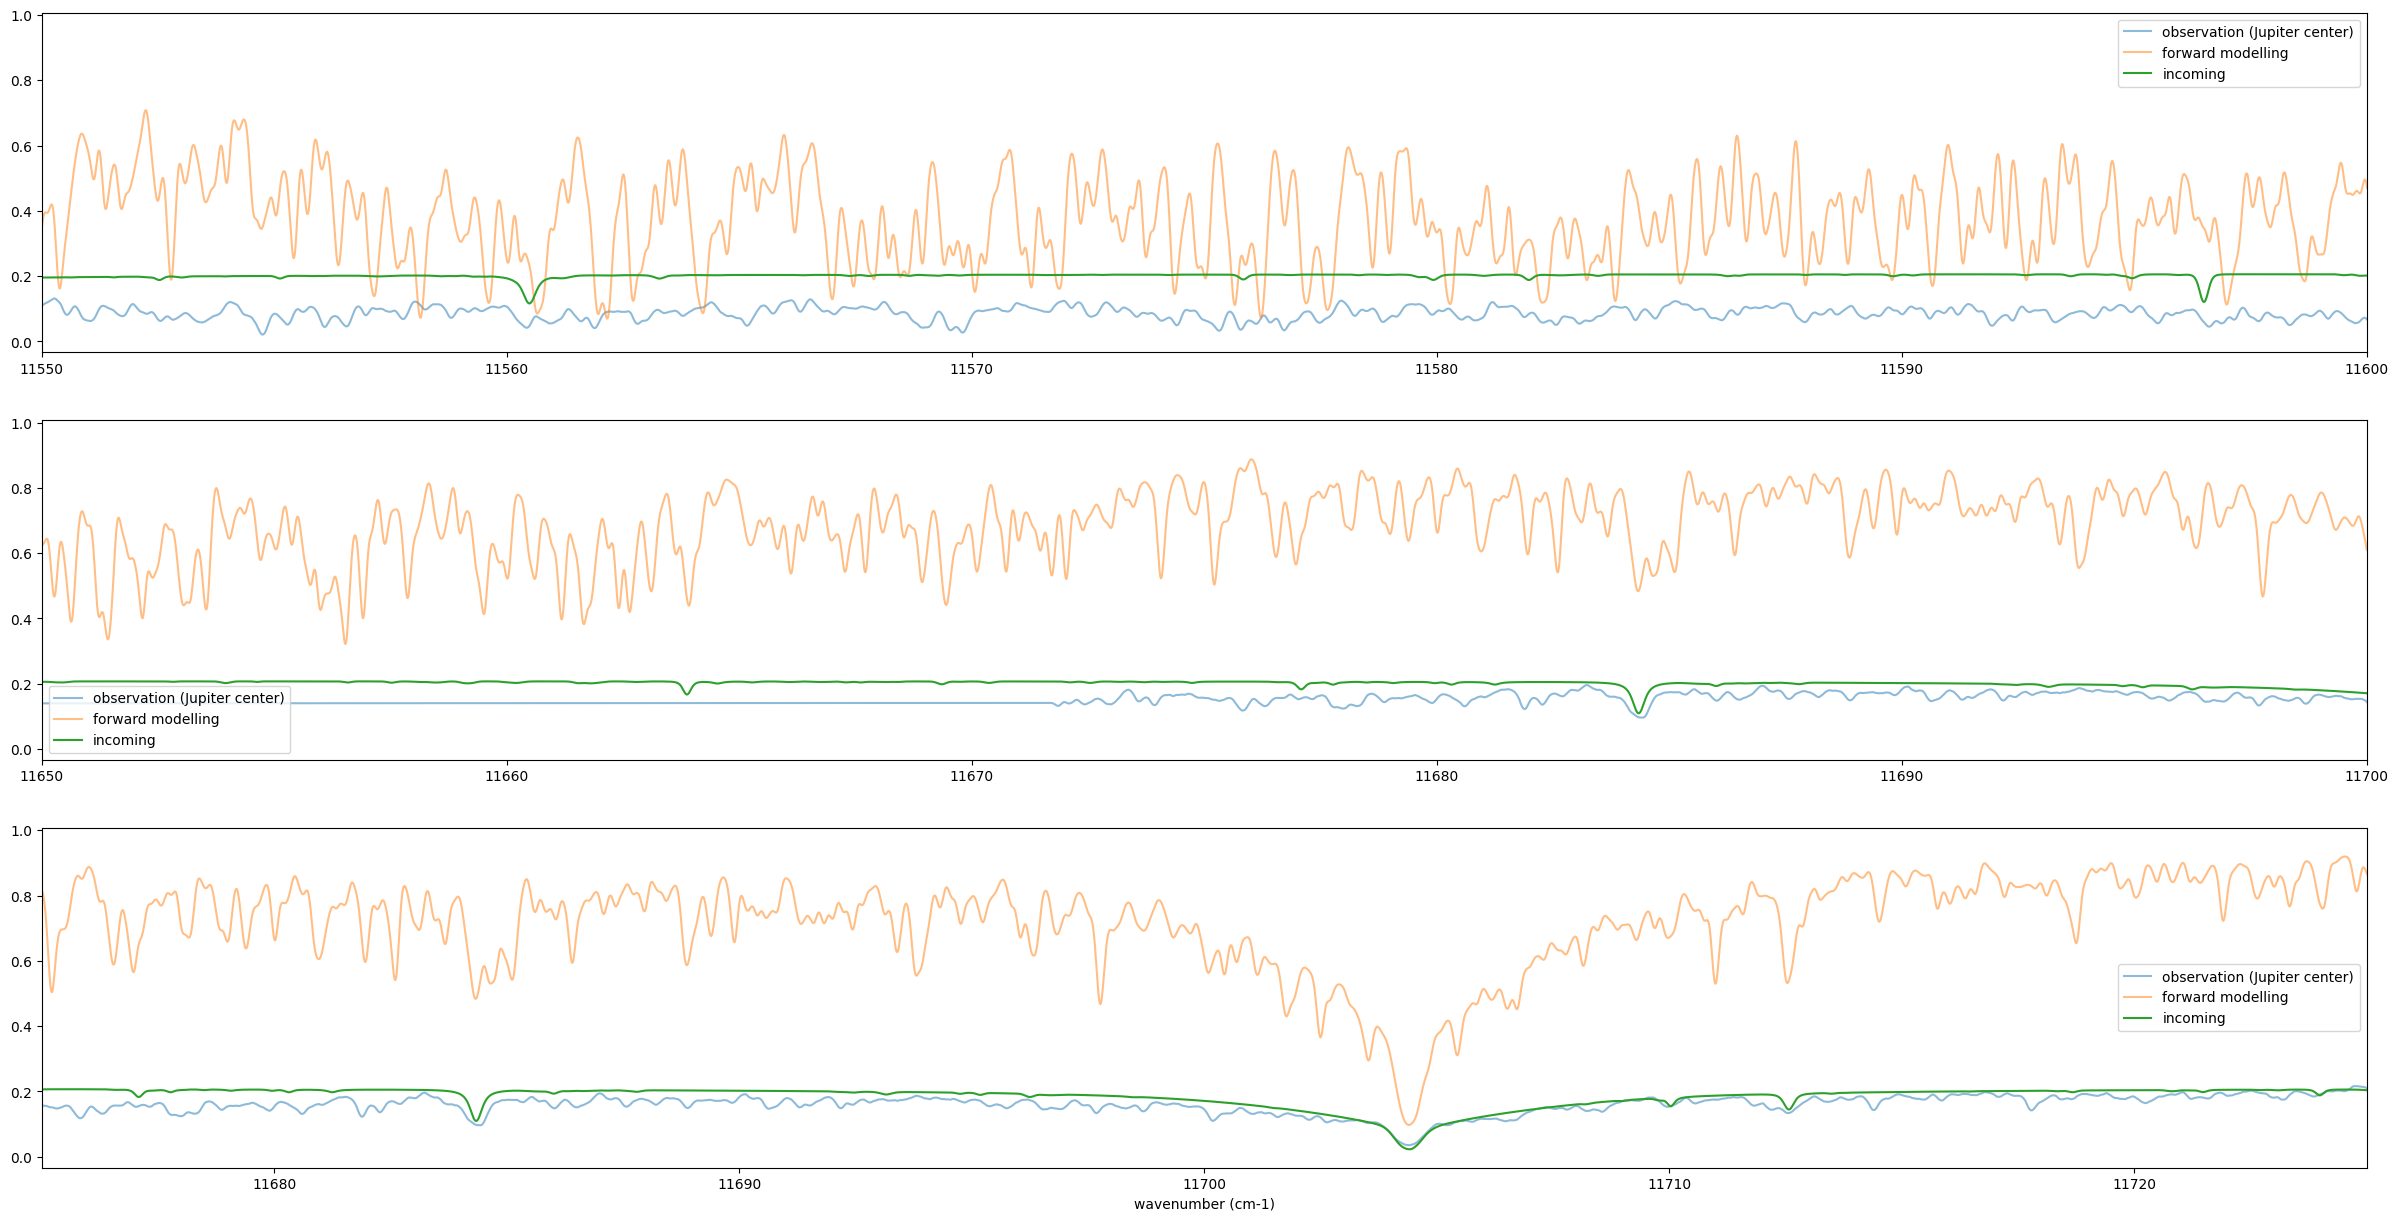

In [31]:
fig = plt.figure(figsize=(30,15))
ax = fig.add_subplot(311)
plt.plot(nus_obs,rspec,alpha=0.5,label="observation (Jupiter center)")
plt.plot(nus,Fr_samp,alpha=0.5,label="forward modelling")
plt.plot(nus*(1-vpercp2),incoming_flux*0.2, label="incoming")
plt.legend()
plt.xlim(11550,11600)

ax = fig.add_subplot(312)
plt.plot(nus_obs,rspec,alpha=0.5,label="observation (Jupiter center)")
plt.plot(nus,Fr_samp,alpha=0.5,label="forward modelling")
plt.plot(nus*(1-vpercp2),incoming_flux*0.2, label="incoming")
plt.legend()
plt.xlim(11650,11700)

ax = fig.add_subplot(313)
plt.plot(nus_obs,rspec,alpha=0.5,label="observation (Jupiter center)")
plt.plot(nus,Fr_samp,alpha=0.5,label="forward modelling")
plt.plot(nus*(1-vpercp2),incoming_flux*0.2, label="incoming")
plt.legend()
plt.xlim(11675,11725)

plt.xlabel("wavenumber (cm-1)")
plt.savefig("Jupiter_forward_1.png")
plt.show()